## Autocorrelation function (ACF)

Given a continuous function of time $x(t)$, the autocorrelation function $c(\tau)$ is defined as below:

$$
    c(\tau) = \int_{0}^{+ \infty} \, x(t) \, x(t + \tau) \, dt
$$

If $x(t)$ is periodic with period $T$:

$$
    c(\tau) = \lim_{T \rightarrow +\infty} \frac{1}{T} \, \int_{0}^{T} \, x(t) \, x(t + \tau) \, dt
$$

That is the limit of the integral mean value. Let's see some examples and important properties in practice

In [1]:
import sympy as smp # Only SymPy
from sympy import latex # To LaTeXify SymPy expressions

In [2]:
# Define symbols
tau, t = smp.symbols('tau, t', real = True, nonnegative = True, constant = False)
T = smp.symbols('T', real = True, positive = True, constant = True)

### ACF of a constant

To compute the autocorrelation function of a constant $C$, we shall use the definition for periodic functions

In [3]:
C = smp.symbols('C', real = True, nonzero = True, constant = True) # Constant C

In [4]:
corr = 1 / T * smp.Integral(C * C, (t, 0, T)) # Definition of autocorrelation for a constant
corr

Integral(C**2, (t, 0, T))/T

In [5]:
corr.doit() # Just do it!

C**2

### ACF of a straight line

A straight line doesn't admit an ACF. We can only compute it partially

In [6]:
m, q = smp.symbols('m, q', real = True, nonzero = True, constant = True) # m slope, q interception

In [7]:
x = m * t + q # x(t) = m * t + q
corr = smp.Integral(x * x.subs(t, t + tau), (t, 0, T)) # Partial
corr

Integral((m*t + q)*(m*(t + tau) + q), (t, 0, T))

In [8]:
corr = corr.doit().expand().collect(tau)
corr # The limit for T approaching +infinity is divergent. This is the equation of a straight line

T**3*m**2/3 + T**2*m*q + T*q**2 + tau*(T**2*m**2/2 + T*m*q)

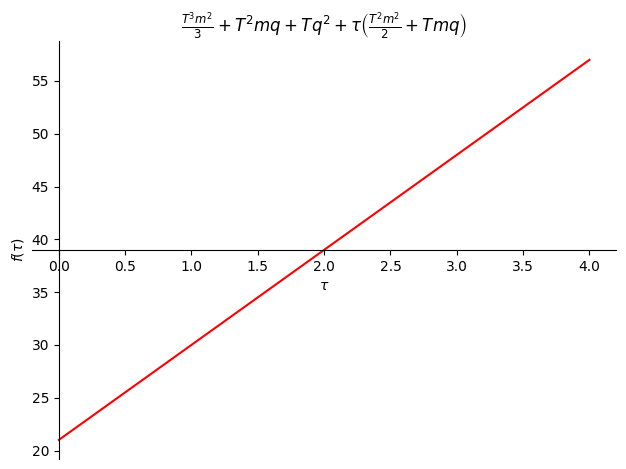

In [9]:
numerical = {
    m: 1.5,
    q: - 1.5,
    T: 4.0
}

smp.plot(corr.subs(numerical), (tau, 0.0, 4.0), title = fr'${latex(corr)}$', line_color = 'red') # Fast plot by SymPy

### ACF of exponential

Let's compute the autocorrelation function of:

$$
    x(t) = \alpha \, e^{\beta \, t}
$$

With no rules on the signs of $\alpha$ and $\beta$

In [10]:
a, b = smp.symbols('alpha, beta', real = True, nonzero = True, constant = True) # alpha and beta
x = a * smp.exp(b * t)
corr = smp.Integral(x * x.subs(t, t + tau), (t, 0, T))
corr # (Remember T approaches +infinity)

Integral(alpha**2*exp(beta*t)*exp(beta*(t + tau)), (t, 0, T))

In [11]:
corr = corr.doit().expand() # Result
corr

alpha**2*exp(2*T*beta)*exp(beta*tau)/(2*beta) - alpha**2*exp(beta*tau)/(2*beta)

If $\beta$ is positive, the limit for $T$ approaching to +$\infty$ is divergent. But, if $\beta$ is negative, the ACF exists:

$$
c(\tau) = \frac{\alpha ^ 2}{2 \, |\beta|} \, e^{- |\beta| \tau}
$$

### ACF of sine and cosine

Let's compute the ACF for a wave:

$$
    x(t) = A \sin(\omega t + \phi)
$$

We'll use the periodic definition

In [12]:
A, omega = smp.symbols('A, omega', real = True, positive = True, constant = True) # A and omega
phi = smp.symbols('phi', real = True, constant = True) # Phi
x = A * smp.sin(omega * t + phi) # Wave
corr = 1 / T * smp.Integral(x * x.subs(t, t + tau), (t, 0, T)) # Exact periodic definition, with T approaching to +infinity
corr

Integral(A**2*sin(omega*t + phi)*sin(omega*(t + tau) + phi), (t, 0, T))/T

In [13]:
corr = corr.doit().trigsimp().expand() # Computation
corr

A**2*cos(omega*tau)/2 + A**2*sin(omega*tau + 2*phi)/(4*T*omega) - A**2*sin(2*T*omega + omega*tau + 2*phi)/(4*T*omega)

The limit for $T$ approaching +$\infty$ yields:

$$
    c(\tau) = \frac{A ^ 2}{2} \cos(\omega \tau)
$$

The information about the initial phase $\phi$ is lost

### ACF of rational functions

Let's compute the ACF of:

$$
    x(t) = \frac{a}{b + c \, t}
$$

No rules on the signs of $a$, $b$ and $c$. We require $a, b, c \neq 0$

In [14]:
a, b, c = smp.symbols('a, b, c', real = True, nonzero = True, constant = True) # a, b, c != 0
x = a / (b + c * t)
corr = smp.Integral(x * x.subs(t, t + tau), (t, 0, smp.oo)) # Exact definition applied
corr

Integral(a**2/((b + c*t)*(b + c*(t + tau))), (t, 0, oo))

In [15]:
corr = corr.doit().simplify() # ACF exists, it's not as simply as it looks though
corr

a**2*(-log(b/c) + log((b + c*tau)/c))/(c**2*tau)

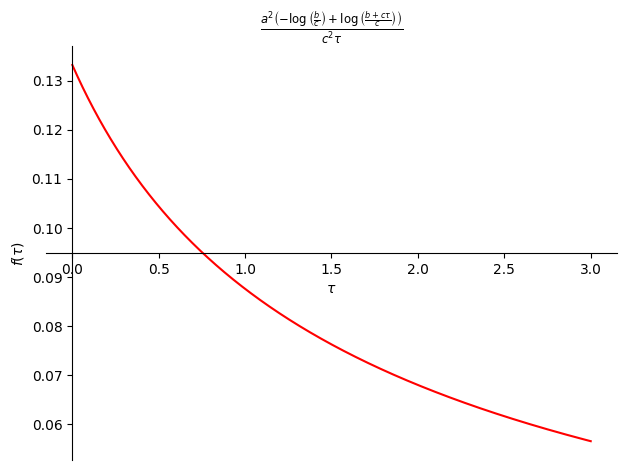

In [16]:
numerical = {
    a: 1.0,
    b: 2.5,
    c: 3.0
}

smp.plot(corr.subs(numerical), (tau, 0.001, 3.0), title = fr'${latex(corr)}$', line_color = 'red') # Fast plot by SymPy

In [17]:
smp.series( # Taylor approximation of the correlation function near tau = 0
    expr = corr,
    x = tau,
    x0 = 0,
    n = 1
)

a**2/(b*c) + O(tau)